# PalmerMorphoBench

**Objectif.** Comparer plusieurs modèles de classification multiclasses à partir de mesures morphométriques, mesurer leur performance et discuter les limites. Le notebook est autonome : il relance l'expérience à partir du CSV du dépôt. Les sorties ci-dessous ont été exécutées et conservées.

**Données.** 344 manchots, trois espèces. Source : [palmerpenguins](https://github.com/allisonhorst/palmerpenguins/blob/main/inst/extdata/penguins.csv), collectées par Kristen Gorman et Palmer Station LTER ; [licence CC0](https://github.com/allisonhorst/palmerpenguins#license).

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from IPython.display import display
from sklearn.metrics import ConfusionMatrixDisplay
from penguins_ml.experiment import FEATURES, load_data, run_experiment

frame = load_data()
display(frame.head())

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## 1. Explorer les données

La cible est déséquilibrée. Deux observations n'ont aucune des quatre mesures physiques ; l'imputation médiane est faite **dans chaque pli d'entraînement**, jamais sur l'ensemble complet avant la validation croisée.

,effectif,part
species,,
Adelie,152,0.442
Chinstrap,68,0.198
Gentoo,124,0.360


,valeurs manquantes
bill_length_mm,2
bill_depth_mm,2
flipper_length_mm,2
body_mass_g,2


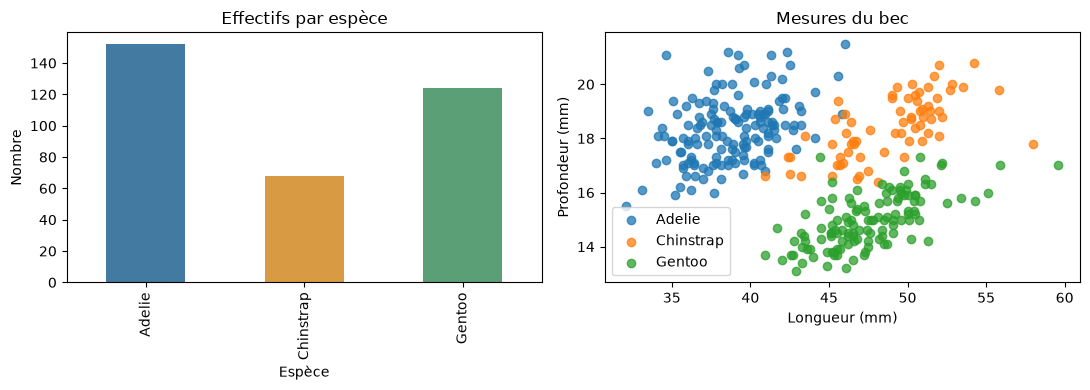

In [2]:
overview = pd.DataFrame({
    "effectif": frame["species"].value_counts().sort_index(),
    "part": frame["species"].value_counts(normalize=True).sort_index().round(3),
})
display(overview)
display(frame[FEATURES].isna().sum().rename("valeurs manquantes").to_frame())

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
overview["effectif"].plot.bar(ax=axes[0], color=["#427AA1", "#D89A42", "#5A9F75"])
axes[0].set(title="Effectifs par espèce", xlabel="Espèce", ylabel="Nombre")
for species, subset in frame.groupby("species"):
    axes[1].scatter(subset["bill_length_mm"], subset["bill_depth_mm"], label=species, alpha=0.75)
axes[1].set(title="Mesures du bec", xlabel="Longueur (mm)", ylabel="Profondeur (mm)")
axes[1].legend()
plt.tight_layout()
plt.show()

## 2. Comparer les modèles

**Variables utilisées :** longueur et profondeur du bec, longueur de nageoire, masse. L'île, le sexe et l'année sont exclus pour mesurer ce que permet la morphologie seule.

Le découpage est stratifié (80 % entraînement, 20 % test ; graine 42). Une validation croisée stratifiée à cinq plis sur l'entraînement compare une baseline majoritaire, une régression logistique, les 7 plus proches voisins et une forêt aléatoire. Le **F1 macro moyen en validation croisée** choisit le modèle final. Accuracy et balanced accuracy complètent l'analyse. Les pipelines ajustent l'imputation et la normalisation à l'intérieur de chaque pli.

In [3]:
results = run_experiment()
comparison = pd.DataFrame(results["comparisons"]).set_index("model")
display(comparison.round(3))
print(f"Entraînement : {results['train_rows']} lignes ; test : {results['test_rows']} lignes")
print(f"Modèle choisi sur validation croisée : {results['selected_model']}")

,cv_f1_macro_mean,cv_f1_macro_std,cv_balanced_accuracy_mean,cv_accuracy_mean,test_f1_macro,test_balanced_accuracy,test_accuracy
model,,,,,,,
K plus proches voisins,0.976,0.037,0.972,0.982,1.000,1.000,1.000
Régression logistique,0.969,0.033,0.966,0.975,1.000,1.000,1.000
Forêt aléatoire,0.950,0.038,0.948,0.960,0.983,0.989,0.986
Baseline majoritaire,0.205,0.003,0.333,0.444,0.202,0.333,0.435


Entraînement : 275 lignes ; test : 69 lignes
Modèle choisi sur validation croisée : K plus proches voisins


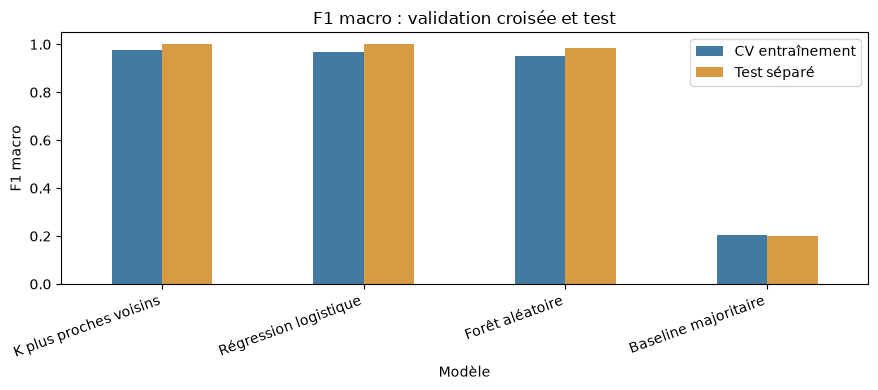

In [4]:
chart = comparison[["cv_f1_macro_mean", "test_f1_macro"]].plot.bar(
    figsize=(9, 4), ylim=(0, 1.05), color=["#427AA1", "#D89A42"]
)
chart.set(title="F1 macro : validation croisée et test", xlabel="Modèle", ylabel="F1 macro")
chart.legend(["CV entraînement", "Test séparé"])
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

## 3. Examiner les erreurs du modèle sélectionné

La matrice affiche les vraies classes en lignes et les prédictions en colonnes. Le rapport par classe aide à voir si une bonne moyenne cache une espèce moins bien reconnue.

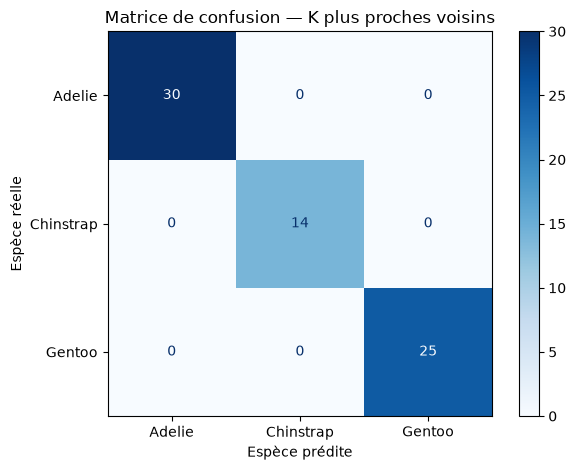

,precision,recall,f1-score,support
Adelie,1.0,1.0,1.0,30.0
Chinstrap,1.0,1.0,1.0,14.0
Gentoo,1.0,1.0,1.0,25.0
macro avg,1.0,1.0,1.0,69.0
weighted avg,1.0,1.0,1.0,69.0


In [5]:
labels = results["class_labels"]
matrix_plot = ConfusionMatrixDisplay(np.asarray(results["confusion_matrix"]), display_labels=labels).plot(cmap="Blues", values_format="d")
matrix_plot.ax_.set(xlabel="Espèce prédite", ylabel="Espèce réelle")
plt.title(f"Matrice de confusion — {results['selected_model']}")
plt.tight_layout()
plt.show()

report = pd.DataFrame({name: value for name, value in results["classification_report"].items() if isinstance(value, dict)}).T
display(report.round(3))

## 4. Conclusions

- Le meilleur modèle selon le **F1 macro en validation croisée** est **K plus proches voisins**, avec **0.976 ± 0.037** sur les cinq plis. La baseline majoritaire atteint **0.205** : l'écart montre que les mesures physiques apportent une information utile.
- Sur les **69 observations de test** réservées, le modèle sélectionné obtient **F1 macro 1.000**, **balanced accuracy 1.000** et **accuracy 1.000**. La matrice comporte **0 erreur(s)**.
- Le test est petit ; ces valeurs peuvent varier avec un autre découpage. Les observations concernent seulement trois îles et les années 2007–2009. Une validation sur d'autres lieux et périodes serait nécessaire avant toute utilisation externe.
- Le tableau affiche aussi les scores de test des autres modèles pour transparence, mais le choix ci-dessus a été fixé par la validation croisée sur l'entraînement. Ces résultats ne sont pas une recherche d'hyperparamètres sur le test.
